## **geozl high-level API**

geozl compresses a raster tile through one OpenZL graph chosen for that tile. This notebook runs the whole flow end to end on a real elevation tile, so you can see what each call does and reproduce every number.

Three calls cover it. `profile` measures every candidate graph, `compress` runs the search and returns the frame, `decompress` gives the array back.

In [1]:
!pip install geozl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 70.9 MB/s eta 0:00:00


### **The tile**

A 512x512 window of the Copernicus GLO-30 DEM over the Mont Blanc massif, public on AWS. Elevation in whole metres, so int16 holds it exactly. Smooth terrain is where spatial predictors shine, small residuals against neighbours.

In [2]:
import numpy as np
import rasterio
from rasterio.windows import Window
import geozl

url = ("https://copernicus-dem-30m.s3.amazonaws.com/"
       "Copernicus_DSM_COG_10_N45_00_E006_00_DEM/"
       "Copernicus_DSM_COG_10_N45_00_E006_00_DEM.tif")
with rasterio.open(url) as src:
    tile = np.round(src.read(1, window=Window(1000, 1000, 512, 512))).astype(np.int16)

raw = tile.nbytes
print(tile.shape, tile.dtype, f"{raw/1e6:.2f} MB")

(512, 512) int16 0.52 MB


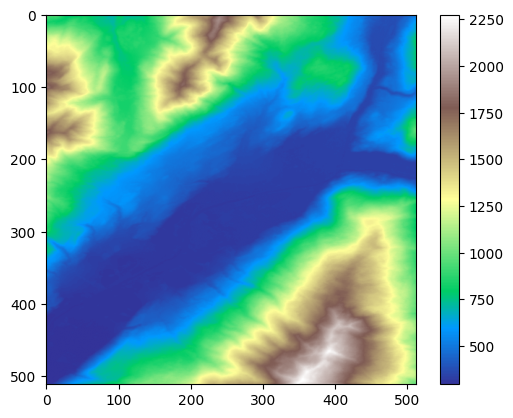

In [3]:
import matplotlib.pyplot as plt
plt.imshow(tile, cmap="terrain")
plt.colorbar()

### **What a graph is**

Every candidate has the same shape: an optional **predictor**, then **zigzag**
to fold the signed residual to unsigned, then a **backend** that does the
actual coding. The recipe string names the pieces, e.g.
`planar>zigzag>transpose>entropy`.

**Predictors** (the `method` prior seeds the search from one of these):

- `planar` predicts each pixel from its neighbours as `W + N - NW`, the local
  gradient. Good default for smooth fields.
- `delta_w` and `delta_n` are the plain difference from the west or north
  neighbour.
- `med` is the median predictor (JPEG-LS style): picks among `W`, `N` and
  `W+N-NW` by the local gradient. Best ratio on many tiles, slower to decode.
- `average` predicts from the average of neighbours.
- `wp_static` fits a small weighted predictor to the tile and stores the
  weights in the frame header.
- `delta_1d` is OpenZL's built-in 1d integer delta.
- `id` uses no predictor: the raw stream goes straight to a backend. This is
  the escape hatch for a tile a predictor does not help.

**Backends and layout** (what closes the graph):

- `entropy` is adaptive FSE/Huffman.
- `zstd` and `field_lz` are LZ, which also catch repetition entropy alone
  misses.
- `transpose>...` first splits the int16 into byte lanes (the low byte and the
  high byte as separate streams), then codes them. This is the byte-shuffle
  that blosc and EOPF use. `id>transpose>zstd` is exactly the EOPF baseline.
- `store_lo` transposes, then stores the low lane raw (it is sensor noise, not
  worth coding) and entropy-codes the high lanes. This wins on Sentinel-2
  where the low byte is irreducible noise.

### **profile: measure the candidates**

`profile` compresses and decompresses every graph in the grid and returns one row per graph. The timing runs in C with the checksum off, so the speed numbers are the pure codec, not the Python call or frame verification. It is a benchmark you run to decide, not part of the compress path.

Arguments:

- `tile` the array (native byte order).
- `method` the predictor prior. `"planar"` builds the grid from `planar` and
  `id`; `None` sweeps every predictor; `"none"` is the `id` branch alone.
- `reps` how many times each graph is compressed and decompressed to time it.
  The best (fastest) of the reps is kept.
- `max_error` profiles the lossy path (see below); `width` sets the row width
  for a 1d tile.

Each row has `ratio` (raw over compressed), `encode_mbps` and `decode_mbps` (measured throughput), and `shannon_pct` (frame size against the tile's order-0 entropy; over 100 means the graph beat that entropy by finding structure the byte histogram misses).

In [4]:
rows = geozl.profile(tile, method=None, reps=20, max_error=0)

print(f"{'graph':32} {'ratio':>6} {'enc MB/s':>9} {'dec MB/s':>9} {'shan%':>6}")
for r in rows:
    print(f"{r['graph']:32} {r['ratio']:6.2f} {r['encode_mbps']:9.1f} "
          f"{r['decode_mbps']:9.1f} {r['shannon_pct']:6.0f}")

graph                             ratio  enc MB/s  dec MB/s  shan%
planar>zigzag>transpose>entropy    4.50     369.0     811.0    346
planar>zigzag>entropy              4.49     168.7     804.9    345
wp_static>zigzag>transpose>entropy   4.48      26.7     302.3    345
wp_static>zigzag>entropy           4.46      25.1     453.1    343
wp_static>zigzag>transpose>zstd    4.21      20.4     302.8    324
planar>zigzag>transpose>zstd       4.14      65.9     758.3    319
med>zigzag>transpose>zstd          3.87      66.7     314.2    298
med>zigzag>transpose>entropy       3.84     350.1     313.5    295
med>zigzag>entropy                 3.83     154.0     312.4    295
wp_static>zigzag>field_lz          3.83      15.5     339.5    294
average>zigzag>transpose>zstd      3.71      68.2     577.6    286
planar>zigzag>field_lz             3.71      34.1     379.3    285
med>zigzag>field_lz                3.58      33.2     217.2    275
average>zigzag>field_lz            3.58      33.7     375.8 

Read the top rows against `id>transpose>zstd`, the EOPF/blosc baseline.

### **compress: run it for real**

`compress` runs one graph. `method` names it and that graph encodes the tile,
so the search happens once in `profile` and never again at compress time.

The recipe goes in exactly as `profile` spells it in the `graph` column. It also
has to apply to the element width: `transpose` and `store_lo` split each sample
into byte lanes, so they want 2 to 8 bytes and will refuse a `uint8` tile.

In [5]:
best = rows[0]['graph']
frame = geozl.compress(tile, method=best)
print(best, f"{raw/len(frame):.2f}x")

planar>zigzag>transpose>entropy 4.50x


Any row of the table is a valid `method`, so you can compress with the top few
and compare the frames the search was ranking.

In [6]:
for row in rows[:3]:
    frame = geozl.compress(tile, method=row['graph'])
    print(f"{raw/len(frame):5.2f}x  {row['graph']}")

 4.50x  planar>zigzag>transpose>entropy
 4.49x  planar>zigzag>entropy
 4.48x  wp_static>zigzag>transpose>entropy


### **max_error: bounded-error lossy**

By default `compress` is lossless, and so is any `max_error` of 0 or less. Pass a
positive `max_error` and it prepends a quantisation step that trades exactness for
ratio, with a hard guarantee: no reconstructed value moves by more than `max_error`.

The quantiser is uniform. With step $\Delta = 2\cdot\text{max\_error}$:

$$q = \operatorname{round}\!\left(\frac{x}{\Delta}\right)
\qquad \hat{x} = q\,\Delta
\qquad |x - \hat{x}| \le \frac{\Delta}{2}$$

The rounding to the nearest multiple of $\Delta$ is what costs at most $\Delta/2$. What travels in the frame depends on the type. On integers the encoder stores $\hat{x}$ and the decoder just copies it. On floats it stores the index $q$, because quantising a float is what turns it into the small integers the downstream predictors compress, and the decoder multiplies back by $\Delta$. Both forms reconstruct the same values.

Two caveats for integers. The step is floored at 1 and truncated to a whole number, since an index cannot be finer than the sample, so `max_error=1.2` gives a step of 2 and behaves exactly like `max_error=1`. And anything below 0.5 gives a step of 1, which is an exact round trip. Truncating the step can only tighten the bound, never loosen it: ask for 2.7 and $\Delta$ becomes 5, so what you actually get is 2.5.

The cell below compresses with `max_error=2`, decompresses, and checks the actual maximum absolute error against the bound.

In [8]:
frame = geozl.compress(tile, method=best, max_error=2.0)
back = geozl.decompress(frame, dtype="int16", width=512)
err = np.abs(back.astype(np.int32) - tile.astype(np.int32)).max()
print(f"ratio {raw/len(frame):.2f}x   max abs error {err}   bound 2")

ratio 8.14x   max abs error 2   bound 2


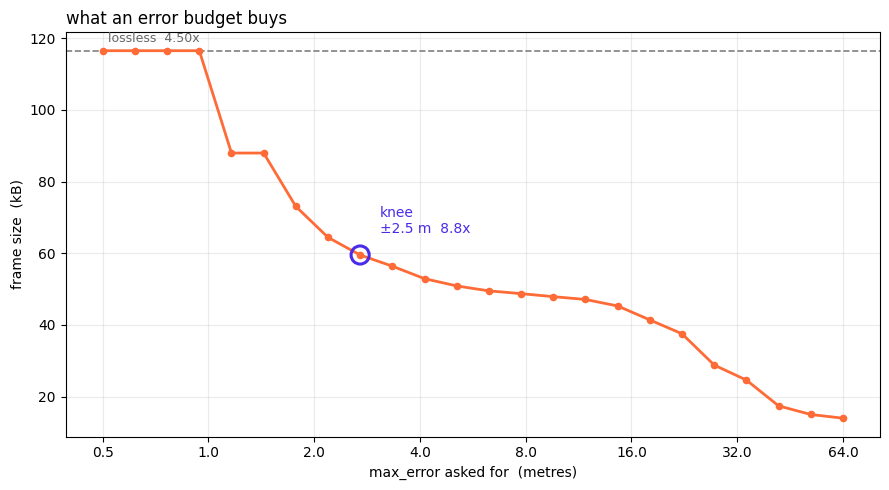

lossless        116.5 kB
knee  ±2.703    59.5 kB    8.81x   step 5, so the bound is ±2.5 m   49% smaller than lossless


In [10]:
#@title **max_error** plot

errors = np.unique(np.round(np.geomspace(0.5, 64, 24), 3))
sizes = np.array([len(geozl.compress(tile, method=best, max_error=float(e)))
                  for e in errors])
lossless = len(geozl.compress(tile, method=best))

# The step is what the encoder actually applies: floored at 1 and truncated to a
# whole number, so the delivered bound is step/2 and never the budget asked for.
steps = np.maximum(1, (2 * errors).astype(int))

# Knee of the curve: the point furthest from the straight line joining the ends,
# measured on the same log axis the plot uses. Past it you keep adding error and
# the frame barely shrinks. A plain gradient does not work here, the step is
# truncated to a whole number so the curve is a staircase.
lx = np.log2(errors)
nx = (lx - lx[0]) / (lx[-1] - lx[0])
ny = (sizes - sizes.min()) / (sizes.max() - sizes.min())
knee = int(np.argmax(np.abs((ny[-1] - ny[0]) * nx - (nx[-1] - nx[0]) * ny
                            + nx[-1] * ny[0] - ny[-1] * nx[0])))

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(lossless / 1e3, color="0.5", ls="--", lw=1.2)
ax.annotate(f"lossless  {raw / lossless:.2f}x", (errors[0], lossless / 1e3),
            xytext=(4, 6), textcoords="offset points", color="0.4", fontsize=9)

ax.plot(errors, sizes / 1e3, color="#FE6B37", lw=2)
ax.scatter(errors, sizes / 1e3, s=20, color="#FE6B37", zorder=3)
ax.scatter(errors[knee], sizes[knee] / 1e3, s=170, facecolor="none",
           edgecolor="#4A2BE8", lw=2.2, zorder=4)
ax.annotate(f"knee\n±{steps[knee] / 2:g} m  {raw / sizes[knee]:.1f}x",
            (errors[knee], sizes[knee] / 1e3), xytext=(14, 16),
            textcoords="offset points", color="#4A2BE8", fontsize=10)

ax.set_xscale("log", base=2)
ax.set_xticks([0.5, 1, 2, 4, 8, 16, 32, 64])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("max_error asked for  (metres)")
ax.set_ylabel("frame size  (kB)")
ax.set_title("what an error budget buys", loc="left")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

print(f"lossless      {lossless/1e3:7.1f} kB")
print(f"knee  ±{errors[knee]:<5g} {sizes[knee]/1e3:7.1f} kB   {raw/sizes[knee]:5.2f}x   "
      f"step {steps[knee]}, so the bound is ±{steps[knee]/2:g} m   "
      f"{100*(1-sizes[knee]/lossless):.0f}% smaller than lossless")

### **decompress: get the array back**

geozl works one level below the array. A tile enters OpenZL as a numeric
stream described by one thing, the bytes per element. An `int16` and a
`uint16` are both "2 bytes" to the frame, which stores the exact bytes but not
the sign, and not that they were 512x512 rather than a flat vector.

So on the way out you tell it how to read the bytes:

- `dtype` reinterprets each element. `"int16"` reads the 2-byte elements as
  signed. Leave it off and you get an unsigned view of the right width.
- `width` reshapes to 2d. Leave it off and you get a flat 1d array.

This is deliberate. geozl is the fast primitive that carries no metadata it
does not need to compress. The layer above it, rumi, owns the dataset, wraps
each frame with the real dtype and shape, and so decompresses with no
arguments at all. The `dtype` and `width` here are for using geozl on its own.

In [11]:
back = geozl.decompress(frame, dtype="int16", width=512)
print(back.shape, back.dtype)

(512, 512) int16


### **The loop**

Measure, pick, run.

In [16]:
rows  = geozl.profile(tile)                                # the slow call, run once
best  = rows[0]['graph']                                   # the winning recipe
frame = geozl.compress(tile, method=best, max_error=2.5)     # the fast call, run always
back  = geozl.decompress(frame, dtype='int16', width=512)
print(best, f"{raw/len(frame):.2f}x lossy")
print(f"{len(frame)/1e6:.2f} MB")
print(f"max error {np.abs(back.astype(np.int32) - tile.astype(np.int32)).max():.2f}")

planar>zigzag>transpose>entropy 8.81x lossy
0.06 MB
max error 2.00


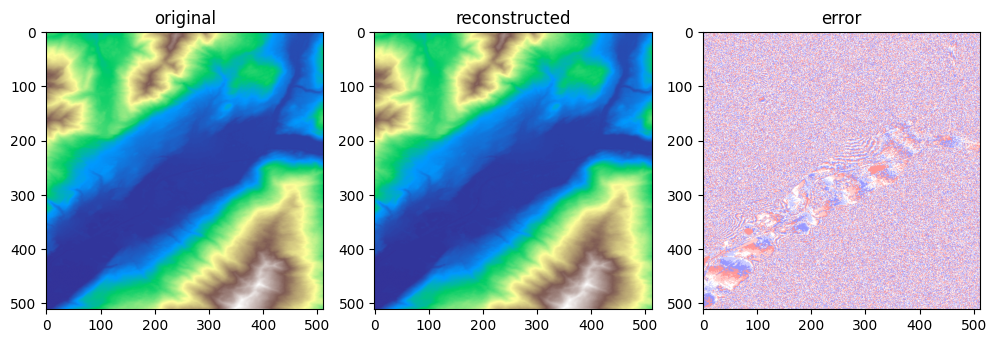

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(tile, cmap="terrain")
ax[0].set_title("original")
ax[1].imshow(back, cmap="terrain")
ax[1].set_title("reconstructed")
ax[2].imshow(tile - back, cmap="bwr", vmin=-5, vmax=5)
ax[2].set_title("error")
plt.tight_layout()
plt.show()